# Sheet 3

- Anna Bütfering
- Lea Neumann
- Juan Provencio

## Task 1
Two moons with an invertible neural network

In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X, _ = make_moons(n_samples=2000, noise=0.1)
X = torch.tensor(X, dtype=torch.float32)

# train-test split
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=True)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: torch.Size([1600, 2])
Test size: torch.Size([400, 2])


In [26]:
# Coupling Layer for RealNVP with forward and inverse methods
class CouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size, mask):
        """
        input_size : dimension of x (2 for two moons)
        hidden_size : width of the internal networks
        mask : boolean tensor of shape (input_size,)
               True  -> passthrough part (x1)
               False -> transformed part (x2)
        """
        super().__init__()
        self.mask = mask

        in_dim = int(mask.sum().item())
        out_dim = input_size - in_dim  # number of transformed dims

        # translation
        self.t_net = nn.Sequential(
            nn.Linear(in_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, out_dim)
        )

        # scaling
        self.s_net = nn.Sequential(
            nn.Linear(in_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, out_dim)
        )


    def forward(self, x):
        x1 = x[:, self.mask]      # unchanged part
        x2 = x[:, ~self.mask]     # transformed part

        t = self.t_net(x1)
        s_tilde = self.s_net(x1)
        s = torch.exp(torch.tanh(s_tilde))  # ensures positive, controlled scaling

        y2 = x2 * s + t

        # combine back into full vector
        y = x.clone()
        y[:, ~self.mask] = y2

        # log-det Jacobian = sum(log(s))
        log_det = torch.sum(torch.log(s), dim=1)

        return y, log_det

    def inverse(self, y):
        y1 = y[:, self.mask]
        y2 = y[:, ~self.mask]

        t = self.t_net(y1)
        s_tilde = self.s_net(y1)
        s = torch.exp(torch.tanh(s_tilde))

        x2 = (y2 - t) / s

        x = y.clone()
        x[:, ~self.mask] = x2

        log_det = -torch.sum(torch.log(s), dim=1)

        return x, log_det

In [27]:
# defining the RealNVP model
class RealNVP(nn.Module):
    def __init__(self, input_size, hidden_size, blocks, device='cpu'):
        super().__init__()
        self.input_size = input_size
        self.blocks = blocks
        self.device = device

        # alternating masks for coupling layers (swap which half is transformed)
        masks = []
        for b in range(blocks):
            if b % 2 == 0:
                mask = torch.tensor([True, False])   # first dim passthrough
            else:
                mask = torch.tensor([False, True])   # second dim passthrough
            masks.append(mask)

        # create coupling layers for each mask
        self.couplings = nn.ModuleList([
            CouplingLayer(input_size, hidden_size, mask)
            for mask in masks
        ])

        if blocks > 1:
            R = torch.stack([self._random_ortho(input_size) for _ in range(blocks - 1)])
            self.register_buffer("rotations", R)
        else:
            self.register_buffer("rotations", torch.empty(0))

    def _random_ortho(self, dim):
        #Create a random orthonormal matrix using QR decomposition.
        a = torch.randn(dim, dim)
        q, r = torch.qr(a)
        if torch.det(q) < 0:
            q[:, 0] = -q[:, 0]
        return q

    def forward(self, x):
        #Encoder: x -> z
        y = x
        log_det_tot = torch.zeros(x.size(0), device=x.device)
        for i, c in enumerate(self.couplings):
            y, logd = c.forward(y)
            log_det_tot = log_det_tot + logd
            # apply rotation if not last block
            if i < len(self.couplings) - 1:
                R = self.rotations[i].to(x.device)
                y = (R @ y.t()).t()
        return y, log_det_tot

    def inverse(self, z):
        #Decoder: z -> x
        y = z
        log_det_tot = torch.zeros(z.size(0), device=z.device)
        for i in reversed(range(len(self.couplings))):
            # inverse rotation if not last in reverse
            if i < len(self.couplings) - 1:
                R = self.rotations[i].to(z.device)
                y = (R.t() @ y.t()).t()  # transpose = inverse for orthonormal
            y, logd = self.couplings[i].inverse(y)
            log_det_tot = log_det_tot + logd
        return y, log_det_tot

    def sample(self, num_samples):
        #Generate samples: z ~ N(0,I) -> x
        z = torch.randn(num_samples, self.input_size, device=next(self.parameters()).device)
        x, _ = self.inverse(z)
        return x.detach().cpu().numpy()

In [28]:
def train_realnvp(model, X_train, training_set_size, mini_batch_size, n_epochs, learning_rate):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    dataset = TensorDataset(X_train[:training_set_size])
    loader = DataLoader(dataset, batch_size=mini_batch_size, shuffle=True)

    losses = []

    for epoch in range(n_epochs):
        epoch_loss = 0.0
        max_recon_error = 0.0   # track worst-case inversion error

        for (x_batch,) in loader:
            
            # forward 
            z, log_det = model.forward(x_batch)

            # inverse consistency check 
            x_reconstructed, _ = model.inverse(z)
            batch_err = torch.max(torch.abs(x_reconstructed - x_batch)).item()
            max_recon_error = max(max_recon_error, batch_err)

            # compute loss 
            log_p_z = -0.5 * torch.sum(z**2, dim=1)
            nll = -(log_p_z + log_det)
            loss = nll.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()


        losses.append(epoch_loss / len(loader))

        # print diagnostics
        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {losses[-1]:.4f} | Max Recon Err: {max_recon_error:.2e}")

    return losses


Training with training set size = 200
Epoch 1/200 | Loss: 0.5864 | Max Recon Err: 4.77e-07
Epoch 2/200 | Loss: 0.4955 | Max Recon Err: 4.77e-07
Epoch 3/200 | Loss: 0.4214 | Max Recon Err: 4.77e-07
Epoch 4/200 | Loss: 0.3660 | Max Recon Err: 7.15e-07
Epoch 5/200 | Loss: 0.3046 | Max Recon Err: 4.77e-07
Epoch 6/200 | Loss: 0.2556 | Max Recon Err: 4.77e-07
Epoch 7/200 | Loss: 0.2082 | Max Recon Err: 3.58e-07
Epoch 8/200 | Loss: 0.1632 | Max Recon Err: 4.77e-07
Epoch 9/200 | Loss: 0.1507 | Max Recon Err: 4.77e-07
Epoch 10/200 | Loss: 0.0986 | Max Recon Err: 4.77e-07
Epoch 11/200 | Loss: 0.0876 | Max Recon Err: 7.15e-07
Epoch 12/200 | Loss: 0.0317 | Max Recon Err: 3.58e-07
Epoch 13/200 | Loss: 0.0172 | Max Recon Err: 4.77e-07
Epoch 14/200 | Loss: 0.0005 | Max Recon Err: 4.77e-07
Epoch 15/200 | Loss: -0.0286 | Max Recon Err: 4.77e-07
Epoch 16/200 | Loss: -0.0283 | Max Recon Err: 3.58e-07
Epoch 17/200 | Loss: -0.0644 | Max Recon Err: 4.77e-07
Epoch 18/200 | Loss: -0.0768 | Max Recon Err: 7.1

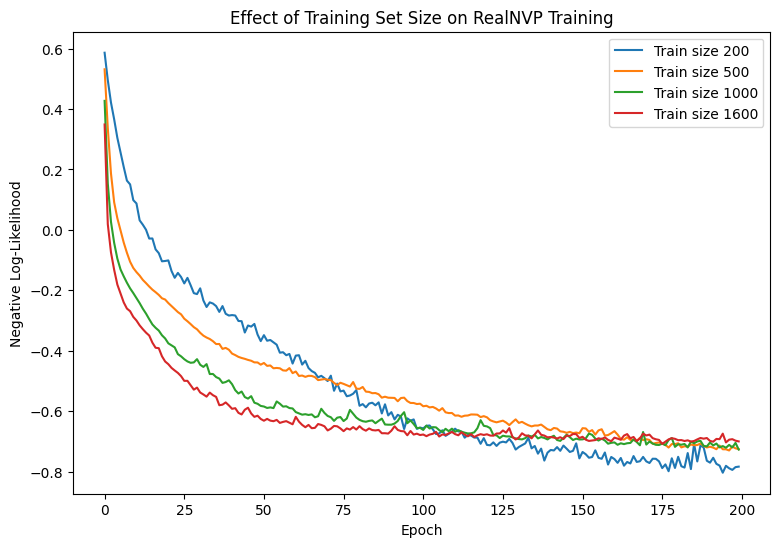

In [29]:
#Training for different training set sizes
hyperparams_size = [
    (200, 128, 200, 0.001, 32, 4),
    (500, 128, 200, 0.001, 32, 4),
    (1000, 128, 200, 0.001, 32, 4),
    (1600, 128, 200, 0.001, 32, 4),
]

results_size = []

for params in hyperparams_size:
    train_size, batch, epochs, lr, hidden, blocks = params

    print(f"\nTraining with training set size = {train_size}")

    model = RealNVP(input_size=2, hidden_size=hidden, blocks=blocks)

    losses = train_realnvp(model,
                           X_train,
                           training_set_size=train_size,
                           mini_batch_size=batch,
                           n_epochs=epochs,
                           learning_rate=lr)

    results_size.append((params, losses))

# Plot 
plt.figure(figsize=(9,6))
for params, losses in results_size:
    train_size = params[0]
    plt.plot(losses, label=f"Train size {train_size}")

plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Effect of Training Set Size on RealNVP Training")
plt.legend()
plt.show()


For the number of epochs in the end, the differences between training set size 1600,1000 and 500 are small, with 1600 only neing slightly better


Training with mini-batch size = 16
Epoch 1/200 | Loss: 0.2293 | Max Recon Err: 5.96e-07
Epoch 2/200 | Loss: -0.0616 | Max Recon Err: 4.77e-07
Epoch 3/200 | Loss: -0.1281 | Max Recon Err: 5.96e-07
Epoch 4/200 | Loss: -0.1732 | Max Recon Err: 4.77e-07
Epoch 5/200 | Loss: -0.2305 | Max Recon Err: 4.77e-07
Epoch 6/200 | Loss: -0.2460 | Max Recon Err: 4.77e-07
Epoch 7/200 | Loss: -0.2855 | Max Recon Err: 4.77e-07
Epoch 8/200 | Loss: -0.2917 | Max Recon Err: 4.77e-07
Epoch 9/200 | Loss: -0.3051 | Max Recon Err: 3.58e-07
Epoch 10/200 | Loss: -0.3393 | Max Recon Err: 4.77e-07
Epoch 11/200 | Loss: -0.3725 | Max Recon Err: 7.15e-07
Epoch 12/200 | Loss: -0.3668 | Max Recon Err: 7.15e-07
Epoch 13/200 | Loss: -0.3705 | Max Recon Err: 4.77e-07
Epoch 14/200 | Loss: -0.3985 | Max Recon Err: 4.77e-07
Epoch 15/200 | Loss: -0.3854 | Max Recon Err: 4.77e-07
Epoch 16/200 | Loss: -0.3686 | Max Recon Err: 4.77e-07
Epoch 17/200 | Loss: -0.3999 | Max Recon Err: 4.77e-07
Epoch 18/200 | Loss: -0.4318 | Max Reco

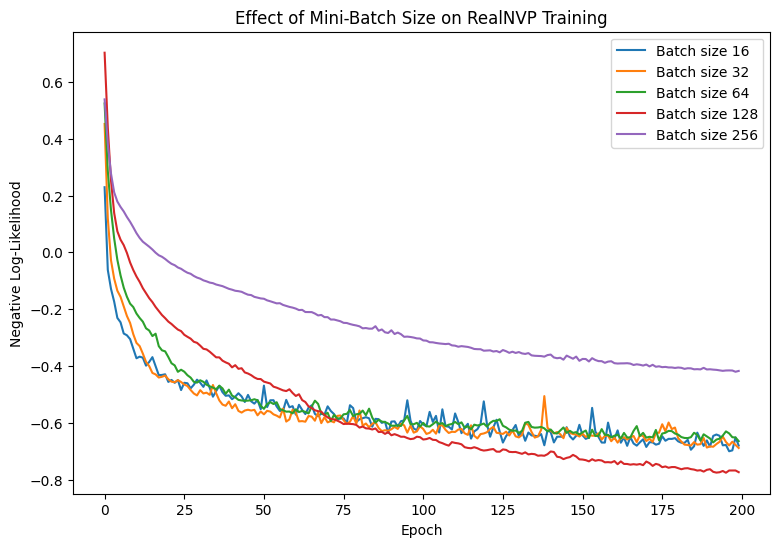

In [30]:
#Training for different mini-batch sizes
hyperparams_batch = [
    (500, 16,  200, 0.001, 32, 4),   
    (500, 32,  200, 0.001, 32, 4),   
    (500, 64,  200, 0.001, 32, 4),   
    (500, 128, 200, 0.001, 32, 4),   
    (500, 256, 200, 0.001, 32, 4)    
]

results_batch = []

for params in hyperparams_batch:
    train_size, batch, epochs, lr, hidden, blocks = params

    print(f"\nTraining with mini-batch size = {batch}")

    model = RealNVP(input_size=2, hidden_size=hidden, blocks=blocks)

    losses = train_realnvp(model,
                           X_train,
                           training_set_size=train_size,
                           mini_batch_size=batch,
                           n_epochs=epochs,
                           learning_rate=lr)

    results_batch.append((params, losses))

# Plot 
plt.figure(figsize=(9,6))
for params, losses in results_batch:
    batch_size = params[1]
    plt.plot(losses, label=f"Batch size {batch_size}")

plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Effect of Mini-Batch Size on RealNVP Training")
plt.legend()
plt.show()



The mini batch size f 32 provides the best results.


Training with 2 RealNVP blocks
Epoch 1/200 | Loss: 0.4374 | Max Recon Err: 7.15e-07
Epoch 2/200 | Loss: 0.1408 | Max Recon Err: 9.54e-07
Epoch 3/200 | Loss: -0.0085 | Max Recon Err: 7.15e-07
Epoch 4/200 | Loss: -0.0607 | Max Recon Err: 7.15e-07
Epoch 5/200 | Loss: -0.0740 | Max Recon Err: 8.34e-07
Epoch 6/200 | Loss: -0.1022 | Max Recon Err: 7.15e-07
Epoch 7/200 | Loss: -0.1213 | Max Recon Err: 7.15e-07
Epoch 8/200 | Loss: -0.1282 | Max Recon Err: 7.15e-07
Epoch 9/200 | Loss: -0.1356 | Max Recon Err: 9.54e-07
Epoch 10/200 | Loss: -0.1478 | Max Recon Err: 8.34e-07
Epoch 11/200 | Loss: -0.1502 | Max Recon Err: 9.54e-07
Epoch 12/200 | Loss: -0.1615 | Max Recon Err: 7.15e-07
Epoch 13/200 | Loss: -0.1674 | Max Recon Err: 7.15e-07
Epoch 14/200 | Loss: -0.1682 | Max Recon Err: 8.34e-07
Epoch 15/200 | Loss: -0.1726 | Max Recon Err: 7.15e-07
Epoch 16/200 | Loss: -0.1699 | Max Recon Err: 9.54e-07
Epoch 17/200 | Loss: -0.1700 | Max Recon Err: 7.15e-07
Epoch 18/200 | Loss: -0.1813 | Max Recon Err

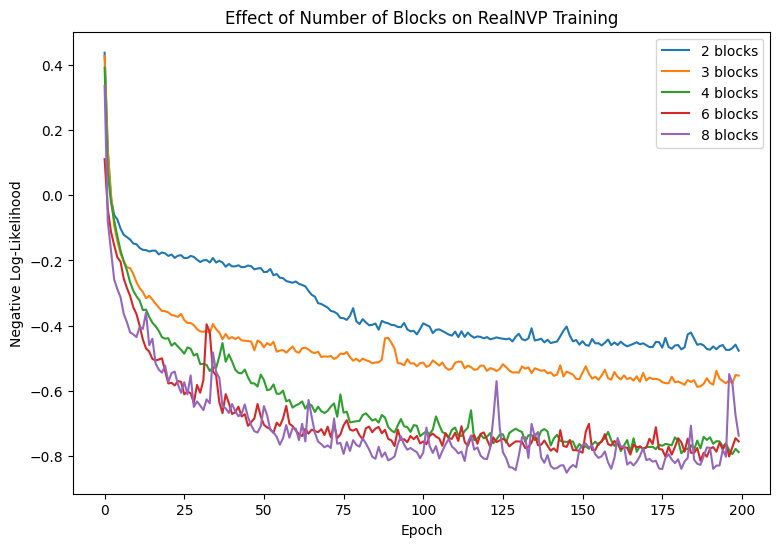

In [31]:
#training with different number of blocks
hyperparams_blocks = [
    (500, 32, 200, 0.001, 32, 2),   
    (500, 32, 200, 0.001, 32, 3),   
    (500, 32, 200, 0.001, 32, 4),   
    (500, 32, 200, 0.001, 32, 6),   
    (500, 32, 200, 0.001, 32, 8),   
]

results_blocks = []

for params in hyperparams_blocks:
    train_size, batch, epochs, lr, hidden, blocks = params

    print(f"\nTraining with {blocks} RealNVP blocks")

    model = RealNVP(input_size=2, hidden_size=hidden, blocks=blocks)

    losses = train_realnvp(model,
                           X_train,
                           training_set_size=train_size,
                           mini_batch_size=batch,
                           n_epochs=epochs,
                           learning_rate=lr)

    results_blocks.append((params, losses))


# ---- Plot curves ----
plt.figure(figsize=(9,6))
for params, losses in results_blocks:
    blocks = params[-1]
    plt.plot(losses, label=f"{blocks} blocks")

plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Effect of Number of Blocks on RealNVP Training")
plt.legend()
plt.show()

8 blocks and 6 blocks only slightly differ. Rest has higher loss.

### Now training with 2 Moons at noise level 0.1 

Epoch 1/200 | Loss: 0.5537 | Max Recon Err: 1.07e-06
Epoch 2/200 | Loss: 0.3823 | Max Recon Err: 1.31e-06
Epoch 3/200 | Loss: 0.2517 | Max Recon Err: 1.07e-06
Epoch 4/200 | Loss: 0.1533 | Max Recon Err: 9.54e-07
Epoch 5/200 | Loss: 0.0788 | Max Recon Err: 9.54e-07
Epoch 6/200 | Loss: 0.0331 | Max Recon Err: 1.19e-06
Epoch 7/200 | Loss: 0.0047 | Max Recon Err: 9.54e-07
Epoch 8/200 | Loss: -0.0043 | Max Recon Err: 9.54e-07
Epoch 9/200 | Loss: -0.0159 | Max Recon Err: 9.54e-07
Epoch 10/200 | Loss: -0.0334 | Max Recon Err: 9.54e-07
Epoch 11/200 | Loss: -0.0570 | Max Recon Err: 9.54e-07
Epoch 12/200 | Loss: -0.0852 | Max Recon Err: 9.54e-07
Epoch 13/200 | Loss: -0.1099 | Max Recon Err: 9.54e-07
Epoch 14/200 | Loss: -0.1291 | Max Recon Err: 9.54e-07
Epoch 15/200 | Loss: -0.1468 | Max Recon Err: 9.54e-07
Epoch 16/200 | Loss: -0.1651 | Max Recon Err: 9.54e-07
Epoch 17/200 | Loss: -0.1822 | Max Recon Err: 8.34e-07
Epoch 18/200 | Loss: -0.2018 | Max Recon Err: 9.54e-07
Epoch 19/200 | Loss: -0.22

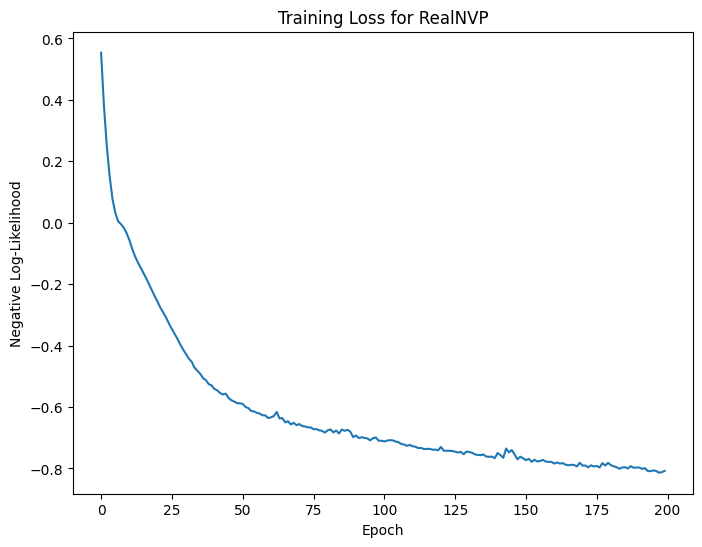

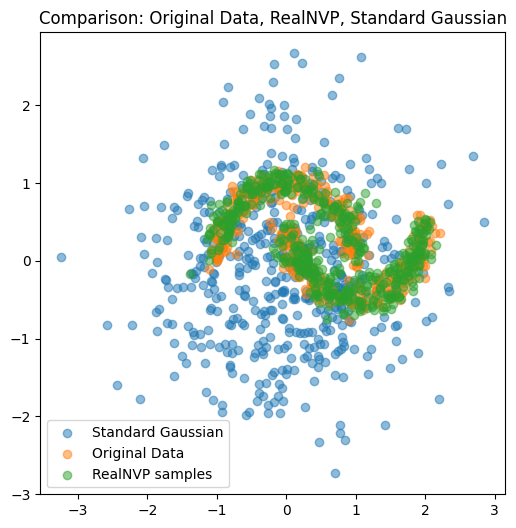

In [32]:
X, _ = make_moons(n_samples=2000, noise=0.1)
X = torch.tensor(X, dtype=torch.float32)
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=True)
model = RealNVP(input_size=2, hidden_size=32, blocks=6)


losses = train_realnvp(model,
                       X_train,
                       training_set_size=train_size,
                       mini_batch_size=batch_size,
                       n_epochs=200,
                       learning_rate=0.001)

#Plot training loss 
plt.figure(figsize=(8,6))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss for RealNVP")
plt.show()

# Generate samples from trained model 
x_gen = model.sample(500)

# Compare to standard Gaussian 
z_gauss = np.random.randn(500, 2)

plt.figure(figsize=(6,6))
plt.scatter(z_gauss[:,0], z_gauss[:,1], alpha=0.5, label="Standard Gaussian")
plt.scatter(X_test[:,0], X_test[:,1], alpha=0.5, label="Original Data")
plt.scatter(x_gen[:,0], x_gen[:,1], alpha=0.5, label="RealNVP samples")
plt.title("Comparison: Original Data, RealNVP, Standard Gaussian")
plt.legend()
plt.show()  

As we can see, the sampled data matches the two moons dataset much better than a randon gaussian distribution.

#### Hexagon task

In [33]:
def generate_hexagon_gmm(radius=1.0, points_per_cluster=300):
    angles = np.linspace(0, 2*np.pi, 6, endpoint=False)  # 6 corners
    centers = np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)
    
    X_list = []
    for c in centers:
        cluster = np.random.randn(points_per_cluster, 2) * (radius/10) + c
        X_list.append(cluster)
    X = np.vstack(X_list)
    return torch.tensor(X, dtype=torch.float32)

# Example
X_gmm = generate_hexagon_gmm(radius=1.0, points_per_cluster=300)

# Train-test split
X_train_gmm, X_test_gmm = train_test_split(X_gmm, test_size=0.2, shuffle=True)


In [34]:
model_gmm = RealNVP(input_size=2, hidden_size=32, blocks=6)

losses_gmm = train_realnvp(model_gmm,
                           X_train_gmm,
                           training_set_size=500,
                           mini_batch_size=31,
                           n_epochs=200,
                           learning_rate=0.001)


Epoch 1/200 | Loss: 0.2417 | Max Recon Err: 4.17e-07
Epoch 2/200 | Loss: 0.0960 | Max Recon Err: 4.77e-07
Epoch 3/200 | Loss: -0.0239 | Max Recon Err: 4.17e-07
Epoch 4/200 | Loss: -0.1397 | Max Recon Err: 5.96e-07
Epoch 5/200 | Loss: -0.2427 | Max Recon Err: 4.77e-07
Epoch 6/200 | Loss: -0.3159 | Max Recon Err: 4.17e-07
Epoch 7/200 | Loss: -0.4542 | Max Recon Err: 3.58e-07
Epoch 8/200 | Loss: -0.5105 | Max Recon Err: 5.96e-07
Epoch 9/200 | Loss: -0.5573 | Max Recon Err: 4.17e-07
Epoch 10/200 | Loss: -0.6084 | Max Recon Err: 4.17e-07
Epoch 11/200 | Loss: -0.6477 | Max Recon Err: 5.36e-07
Epoch 12/200 | Loss: -0.6971 | Max Recon Err: 4.77e-07
Epoch 13/200 | Loss: -0.7114 | Max Recon Err: 4.17e-07
Epoch 14/200 | Loss: -0.7127 | Max Recon Err: 6.56e-07
Epoch 15/200 | Loss: -0.7810 | Max Recon Err: 6.56e-07
Epoch 16/200 | Loss: -0.7875 | Max Recon Err: 5.96e-07
Epoch 17/200 | Loss: -0.8446 | Max Recon Err: 5.96e-07
Epoch 18/200 | Loss: -0.8451 | Max Recon Err: 3.58e-07
Epoch 19/200 | Loss: 

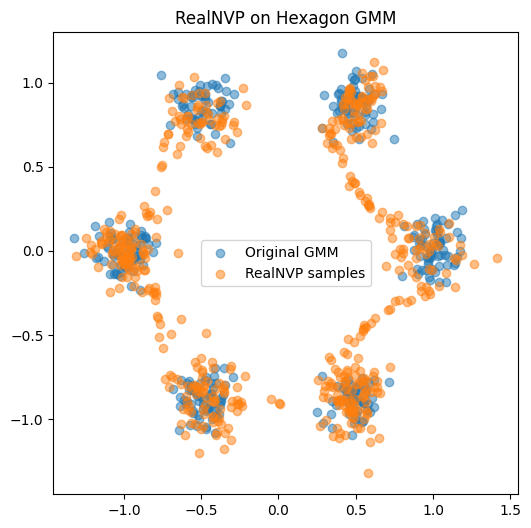

In [35]:
x_gen_gmm = model_gmm.sample(500)

plt.figure(figsize=(6,6))
plt.scatter(X_test_gmm[:,0], X_test_gmm[:,1], alpha=0.5, label="Original GMM")
plt.scatter(x_gen_gmm[:,0], x_gen_gmm[:,1], alpha=0.5, label="RealNVP samples")
plt.title("RealNVP on Hexagon GMM")
plt.legend()
plt.show()


We can definitely see the hexagonal distribution of the data points, our learned samples differ a bit, mostly around the outer conections of the hexagon.

---

## Task 2

Two Moons with a conditional invertible neural network

### Create datasets with labels

In [147]:
# Two Moons Dataset
X, y = make_moons(n_samples=2000, noise=0.1)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# train-test split
X_Mtrain, X_Mtest, y_Mtrain, y_Mtest = train_test_split(X, y, test_size=0.2, shuffle=True)

print("Train size:", X_Mtrain.shape, y_Mtrain.shape)
print("Test size:", X_Mtest.shape, y_Mtest.shape)

Train size: torch.Size([1600, 2]) torch.Size([1600])
Test size: torch.Size([400, 2]) torch.Size([400])


In [148]:
# Hexagon GMM Dataset
def generate_hex_gmm(radius=1.0, points_per_cluster=300):
    angles = np.linspace(0, 2*np.pi, 6, endpoint=False)  # 6 corners
    centers = np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)
    
    X_list = []
    y_list = [] 
    label = 0
    for c in centers:
        cluster = np.random.randn(points_per_cluster, 2) * (radius/10) + c
        X_list.append(cluster)
        labels = np.full(points_per_cluster, label)
        label += 1
        y_list.append(labels)
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Example
X_hex, y_hex = generate_hex_gmm(radius=1.0, points_per_cluster=300)
print(X_hex.shape, y_hex.shape)

#Train-test split
X_Htrain, X_Htest, y_Htrain, y_Htest = train_test_split(X_hex, y_hex, test_size=0.2, shuffle=True)

torch.Size([1800, 2]) torch.Size([1800])


### Implement a conditional invertible neural network

In [149]:
# One-Hot Encoding Function for the labels (conditions)
def oneHot(conds, condition_size):
    '''
    Convert labels to one-hot encoded vectors.
    ---
    y: tensor of shape ([num_samples])
    condition_size: number of categories in labels
    '''
    cond_onehot = torch.zeros(conds.size(0), condition_size)
    for i in range(conds.shape[0]):
        cond_onehot[i, int(torch.sum(conds[i]))] = 1 
    return cond_onehot

# conditions in one-hot format:    
c_Mtrain, c_Mtest, c_Htrain, c_Htest  = oneHot(y_Mtrain, 2), oneHot(y_Mtest, 2), oneHot(y_Htrain, 6), oneHot(y_Htest, 6)
print("Conversion to one-hot format done.")
print("Example input labels:")
print( y_Mtrain[:5])
print("One-hot encoded output:")
print(c_Mtrain[:5,:])

Conversion to one-hot format done.
Example input labels:
tensor([0., 1., 1., 1., 0.])
One-hot encoded output:
tensor([[1., 0.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.]])


In [249]:
# Coupling Layer for RealNVP with forward and inverse methods
class CouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size, condition_size, mask):
        """
        input_size : dimension of x (2 for two moons)
        hidden_size : width of the internal networks
        condition_size : dimension of the one-hot encoded labels (conditions)
        mask : boolean tensor of shape (input_size,)
               True  -> passthrough part (x1)
               False -> transformed part (x2)
        """
        super().__init__()
        self.mask = mask
        self.condition_size = condition_size

        in_dim = int(mask.sum().item()) + condition_size
        #out_dim = 2
        out_dim = input_size - in_dim + condition_size # number of transformed dims
        # translation
        self.t_net = nn.Sequential(
            nn.Linear(in_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, out_dim)
        )

        # scaling
        self.s_net = nn.Sequential(
            nn.Linear(in_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, out_dim)
        )


    def forward(self, x, conds):
        """if conds.shape[0] != x.shape[0] | conds.shape[1] != self.condition_size:
            print("Conditions shape:", conds.shape)
            print("Expected size:", (x.shape[0], self.condition_size))
            raise ValueError("Shape of conditions does not match expected size.")"""

        # unchanged part (unch)
        x_masked = x[:, self.mask]   
        x1 = torch.cat([x_masked,conds],dim=1) 

        # transformed part (trans)
        x2 = x[:, ~self.mask]    
        x2 = torch.cat([x_masked,conds],dim=1)

        t = self.t_net(x1)
        s_tilde = self.s_net(x1)
        s = torch.exp(torch.tanh(s_tilde))  # ensures positive, controlled scaling

        y2 = x2 * s + t #Transformed part including conditions

        y_conds = y2[:, x_masked.shape[1]:] # Extraction of encoded conditions     

        # combine back into full coordinate vector (without conditions):
        y = x.clone()
        y[:, ~self.mask] = y2[:, :x_masked.shape[1]] 

        # log-det Jacobian = sum(log(s))
        log_det = torch.sum(torch.log(s), dim=1)

        return y, y_conds, log_det

    def inverse(self, y, conds): 
        # unchanged part (unch)
        y_masked = y[:, self.mask]   
        y1 = torch.cat([y_masked,conds],dim=1) 

        # transformed part (trans)
        #y2= y[:, ~self.mask]    
        y_masked = y[:, ~self.mask]    
        y2 = torch.cat([y_masked,conds],dim=1)
        #print(y1.shape, y2.shape, conds.shape)

        t = self.t_net(y1)
        s_tilde = self.s_net(y1)
        s = torch.exp(torch.tanh(s_tilde))
        #print(s.shape, "s", t.shape, "t")

        x2 = (y2 - t) / s # Transformed part including conditions

        x_conds = x2[:, y_masked.shape[1]:] # Extraction of reconstructed conditions (These are not discrete, i.e. 1.0 or 0.0, yet.)
        x_labels = x_conds.argmax(dim=1)  # Decoding to original labels
        x_conds = oneHot(x_labels, self.condition_size)  # Re-encoding to one-hot format

        # combine back into full coordinate vector (without conditions):
        x = y.clone()
        x[:, ~self.mask] = x2[:, :y_masked.shape[1]] 

        log_det = -torch.sum(torch.log(s), dim=1)

        #print("Inverse CL done.")

        return x, x_conds, log_det


In [303]:
#Test whether CouplingLayers work
layer = CouplingLayer(input_size=2, hidden_size=128, condition_size=2, mask=torch.tensor([True, False]))
z, z_conds, log_det = layer.forward(X_Mtrain[:5,:], c_Mtrain[:5,:])
x, x_conds, log_det = layer.inverse(z, z_conds)

In [309]:
# defining the conditional Invertible Neural Network (RealNVP model):
class cINN(nn.Module):
    def __init__(self, input_size, hidden_size, condition_size, blocks, device='cpu'):
        super().__init__()
        self.input_size = input_size
        self.blocks = blocks
        self.device = device
        self.condition_size = condition_size

        # alternating masks for coupling layers (swap which half is transformed)
        masks = []
        for b in range(blocks):
            if b % 2 == 0:
                mask = torch.tensor([True, False])   # first dim passthrough
            else:
                mask = torch.tensor([False, True])   # second dim passthrough
            masks.append(mask)

        # create coupling layers for each mask
        self.couplings = nn.ModuleList([
            CouplingLayer(input_size, hidden_size, condition_size, mask)
            for mask in masks
        ])

        if blocks > 1:
            R = torch.stack([self._random_ortho(input_size) for _ in range(blocks - 1)])
            self.register_buffer("rotations", R)
        else:
            self.register_buffer("rotations", torch.empty(0))

    def _random_ortho(self, dim):
        #Create a random orthonormal matrix using QR decomposition.
        a = torch.randn(dim, dim)
        q, r = torch.qr(a)
        if torch.det(q) < 0:
            q[:, 0] = -q[:, 0]
        return q

    def forward(self, x, conds):
        #Encoder: x -> z
        y = x
        log_det_tot = torch.zeros(x.size(0), device=x.device)
        for i, c in enumerate(self.couplings):
            y, y_conds, logd = c.forward(y, conds)
            log_det_tot = log_det_tot + logd
            # apply rotation if not last block
            if i < len(self.couplings) - 1:
                R = self.rotations[i].to(x.device)
                y = (R @ y.t()).t()
        return y, y_conds, log_det_tot

    def inverse(self, z, z_conds):
        #Decoder: z -> x
        y = z
        log_det_tot = torch.zeros(z.size(0), device=z.device)
        for i in reversed(range(len(self.couplings))):
            # inverse rotation if not last in reverse
            if i < len(self.couplings) - 1:
                R = self.rotations[i].to(z.device)
                y = (R.t() @ x.t()).t()  # transpose = inverse for orthonormal
            x, x_conds, logd = self.couplings[i].inverse(y, z_conds)
            log_det_tot = log_det_tot + logd
        return x, x_conds, log_det_tot

    def sample(self, num_samples, conditions):
        #Generate samples: z ~ N(0,I) -> x
        z = torch.randn(num_samples, self.input_size, device=next(self.parameters()).device)
        z_conds = torch.tensor(conditions)[torch.randint(len(conditions), (num_samples,))]
        z_conds = oneHot(z_conds, self.condition_size).to(z.device)
        x, x_conds, _ = self.inverse(z, z_conds)
        return x.detach().cpu().numpy(), x_conds

In [274]:
def train_cINN(model, X_train, c_train, training_set_size, mini_batch_size, n_epochs, learning_rate):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    X = torch.cat([X_train, c_train], dim=1)
    dataset = TensorDataset(X[:training_set_size])
    loader = DataLoader(dataset, batch_size=mini_batch_size, shuffle=True)

    losses = []
    label_loss = []

    for epoch in range(n_epochs):
        epoch_loss = 0.0
        max_recon_error = 0.0   # track worst-case inversion error
        label_err = 0.0

        for (x_batch,) in loader:
            #print("Training batch shape:", x_batch.shape)
            c_batch = x_batch[:, model.input_size:]
            x_batch = x_batch[:, :model.input_size]
            #print("x_batch:", x_batch.shape, "c_batch:", c_batch.shape)
            

            # forward 
            z, z_conds, log_det = model.forward(x_batch, c_batch)

            # inverse consistency check 
            x_reconstructed, c_reconstructed, _ = model.inverse(z, z_conds)
            batch_err = torch.max(torch.abs(x_reconstructed - x_batch)).item()
            max_recon_error = max(max_recon_error, batch_err)

            # compute loss 
            log_p_z = -0.5 * torch.sum(z**2, dim=1)
            nll = -(log_p_z + log_det)
            loss = nll.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() 

            #Evaluate label reconstruction:
            label_recon = (c_batch * c_reconstructed).sum() # dot product for one-hot vectors returns 1 if correctly reconstructed and 0 if not
            label_err += label_recon / c_batch.shape[0]  # average over batch; range [0,1]; Ideally close to 1
            

            #print(f"Label Reconstruction Accuracy: {label_recon_err:.4f}")


        losses.append(epoch_loss / len(loader))
        label_loss.append(label_err / len(loader))

        # print diagnostics
        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {losses[-1]:.4f} | Max Recon Err: {max_recon_error:.2e} | Label Acc: {label_loss[-1]:.3f}")

    return model, losses

In [305]:
TS = [X_Htrain, c_Htrain, 6]
test = [X_Htest, c_Htest, 6]
test_label = c_Htest.argmax(dim=1)

best_params = [32,6, 500,31, 200] # hidden_size, blocks, training_set_size, mini_batch_size, n_epochs

model_Hex = cINN(input_size=2, hidden_size=best_params[0], condition_size=TS[2], blocks=best_params[1])
trained_Hex, losses_Hex = train_cINN(model_Hex, TS[0], TS[1], 
                                     training_set_size= best_params[2], 
                                     mini_batch_size=best_params[3], 
                                     n_epochs=best_params[4], 
                                     learning_rate=0.001)

Epoch 1/200 | Loss: -0.4089 | Max Recon Err: 1.47e+00 | Label Acc: 1.000
Epoch 2/200 | Loss: -1.5272 | Max Recon Err: 1.52e+00 | Label Acc: 1.000
Epoch 3/200 | Loss: -2.8218 | Max Recon Err: 1.61e+00 | Label Acc: 1.000
Epoch 4/200 | Loss: -4.0742 | Max Recon Err: 1.79e+00 | Label Acc: 1.000
Epoch 5/200 | Loss: -5.0340 | Max Recon Err: 1.95e+00 | Label Acc: 1.000
Epoch 6/200 | Loss: -5.5849 | Max Recon Err: 2.14e+00 | Label Acc: 1.000
Epoch 7/200 | Loss: -5.8103 | Max Recon Err: 2.33e+00 | Label Acc: 1.000
Epoch 8/200 | Loss: -5.8928 | Max Recon Err: 2.47e+00 | Label Acc: 1.000
Epoch 9/200 | Loss: -5.9317 | Max Recon Err: 2.57e+00 | Label Acc: 1.000
Epoch 10/200 | Loss: -5.9533 | Max Recon Err: 2.67e+00 | Label Acc: 1.000
Epoch 11/200 | Loss: -5.9654 | Max Recon Err: 2.67e+00 | Label Acc: 1.000
Epoch 12/200 | Loss: -5.9737 | Max Recon Err: 2.75e+00 | Label Acc: 1.000
Epoch 13/200 | Loss: -5.9795 | Max Recon Err: 2.79e+00 | Label Acc: 1.000
Epoch 14/200 | Loss: -5.9835 | Max Recon Err: 2

In [306]:
#Sampling from trained model with all conditions
gen, cond_gen = trained_Hex.sample(1000, conditions=[1,2,3,4,5,0])

# Code distribution of trained model:
z, z_conds, log_det_tot = trained_Hex.forward(test[0], test[1])
# Reconstrucion from code distribution:
x_rec, x_conds_rec, log_det_tot = trained_Hex.inverse(z, z_conds)

# Adjust dtypes etc. for plotting: 
z = z.detach().numpy()
x_rec = x_rec.detach().numpy()
x_conds_rec = x_conds_rec.argmax(dim=1).detach().numpy()
cond_gen = cond_gen.argmax(dim=1)

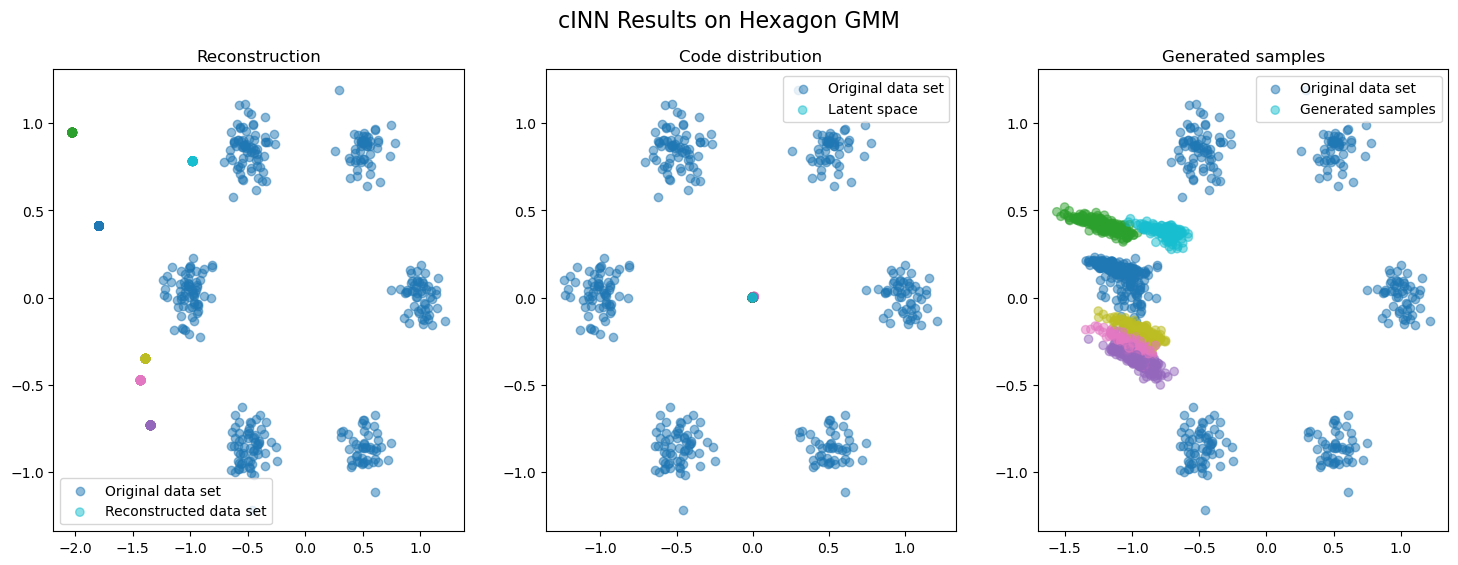

In [307]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

#axes[0].figure(figsize=(6,6))
axes[0].scatter(test[0][:,0], test[0][:,1], alpha=0.5, label="Original data set")#, c=test_label, cmap='tab10')
axes[0].scatter(x_rec[:,0], x_rec[:,1], alpha=0.5, c=x_conds_rec, label="Reconstructed data set", cmap='tab10')
axes[0].set_title("Reconstruction")
axes[0].legend()

axes[1].scatter(test[0][:,0], test[0][:,1], alpha=0.5, label="Original data set")#, c=test_label, cmap='tab10')
axes[1].scatter(z[:,0], z[:,1], alpha=0.5, c=z_conds.argmax(dim=1).detach().numpy(), cmap='tab10', label="Latent space")
axes[1].set_title("Code distribution")
axes[1].legend()

axes[2].scatter(test[0][:,0], test[0][:,1], alpha=0.5, label="Original data set")#, c=test_label, cmap='tab10')
axes[2].scatter(gen[:,0], gen[:,1], alpha=0.5, label="Generated samples", c=cond_gen, cmap='tab10')
axes[2].set_title("Generated samples")
axes[2].legend()
plt.suptitle("cINN Results on Hexagon GMM", fontsize=16)
plt.show()

The conditional invertible neural network is implemented similar to the normal invertible neural network, but with the addition of labels as extra input to the coupling layers. It does not properly work yet.

In [308]:
TS = [X_Mtrain, c_Mtrain, 2]
test = [X_Mtest, c_Mtest, 2]
test_label = c_Htest.argmax(dim=1)

best_params = [32,6, 500,31, 200] # hidden_size, blocks, training_set_size, mini_batch_size, n_epochs

model_Moons = cINN(input_size=2, hidden_size=best_params[0], condition_size=TS[2], blocks=best_params[1])
trained_Moons, losses_Moons = train_cINN(model_Moons, TS[0], TS[1], 
                                     training_set_size= best_params[2], 
                                     mini_batch_size=best_params[3], 
                                     n_epochs=best_params[4], 
                                     learning_rate=0.001)

Epoch 1/200 | Loss: -0.3349 | Max Recon Err: 2.09e+00 | Label Acc: 1.000
Epoch 2/200 | Loss: -1.8803 | Max Recon Err: 1.86e+00 | Label Acc: 1.000
Epoch 3/200 | Loss: -3.3624 | Max Recon Err: 1.90e+00 | Label Acc: 1.000
Epoch 4/200 | Loss: -4.4380 | Max Recon Err: 1.87e+00 | Label Acc: 1.000
Epoch 5/200 | Loss: -5.0605 | Max Recon Err: 1.79e+00 | Label Acc: 1.000
Epoch 6/200 | Loss: -5.3898 | Max Recon Err: 1.73e+00 | Label Acc: 1.000
Epoch 7/200 | Loss: -5.5802 | Max Recon Err: 1.71e+00 | Label Acc: 1.000
Epoch 8/200 | Loss: -5.6941 | Max Recon Err: 1.65e+00 | Label Acc: 1.000
Epoch 9/200 | Loss: -5.7729 | Max Recon Err: 1.64e+00 | Label Acc: 1.000
Epoch 10/200 | Loss: -5.8282 | Max Recon Err: 1.61e+00 | Label Acc: 1.000
Epoch 11/200 | Loss: -5.8696 | Max Recon Err: 1.63e+00 | Label Acc: 1.000
Epoch 12/200 | Loss: -5.8998 | Max Recon Err: 1.60e+00 | Label Acc: 1.000
Epoch 13/200 | Loss: -5.9244 | Max Recon Err: 1.60e+00 | Label Acc: 1.000
Epoch 14/200 | Loss: -5.9421 | Max Recon Err: 1

In [301]:
#Sampling from trained model with all conditions
gen, cond_gen = trained_Moons.sample(1000, conditions=[1,2,3,4,5,0])

# Code distribution of trained model:
z, z_conds, log_det_tot = trained_Moons.forward(test[0], test[1])
# Reconstrucion from code distribution:
x_rec, x_conds_rec, log_det_tot = trained_Moons.inverse(z, z_conds)

# Adjust dtypes etc. for plotting: 
z = z.detach().numpy()
x_rec = x_rec.detach().numpy()
x_conds_rec = x_conds_rec.argmax(dim=1).detach().numpy()
cond_gen = cond_gen.argmax(dim=1)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (400x3 and 7x32)

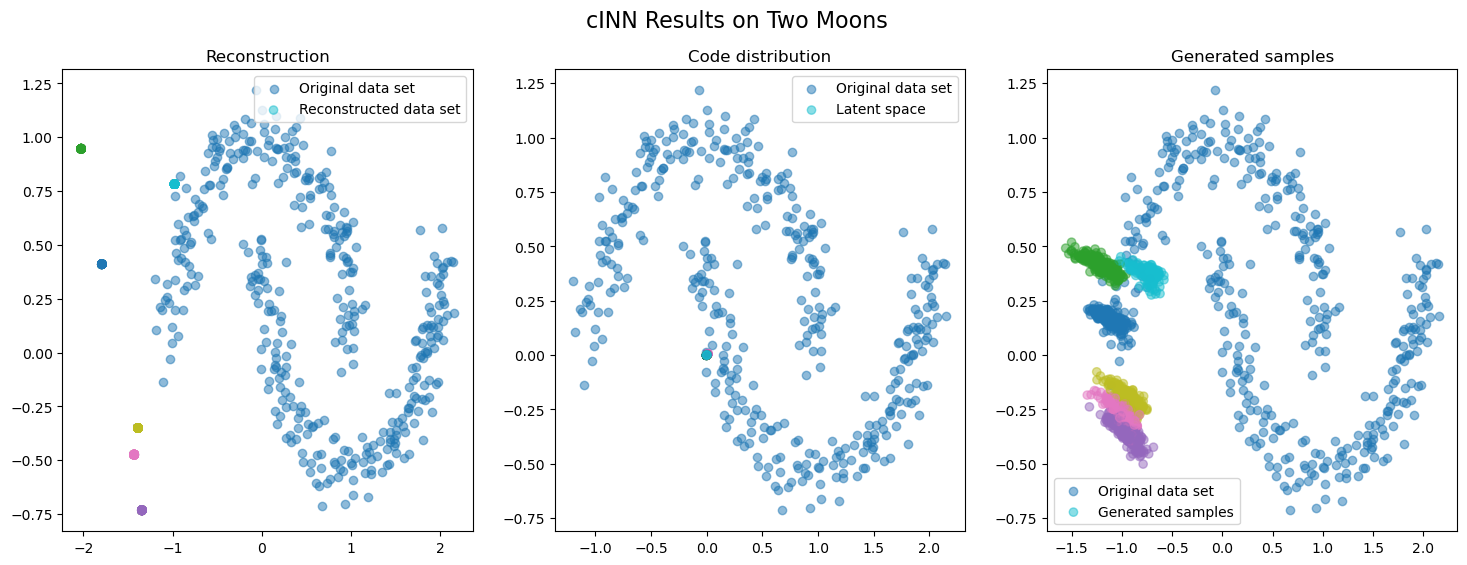

In [310]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

#axes[0].figure(figsize=(6,6))
axes[0].scatter(test[0][:,0], test[0][:,1], alpha=0.5, label="Original data set")#, c=test_label, cmap='tab10')
axes[0].scatter(x_rec[:,0], x_rec[:,1], alpha=0.5, c=x_conds_rec, label="Reconstructed data set", cmap='tab10')
axes[0].set_title("Reconstruction")
axes[0].legend()

axes[1].scatter(test[0][:,0], test[0][:,1], alpha=0.5, label="Original data set")#, c=test_label, cmap='tab10')
axes[1].scatter(z[:,0], z[:,1], alpha=0.5, c=z_conds.argmax(dim=1).detach().numpy(), cmap='tab10', label="Latent space")
axes[1].set_title("Code distribution")
axes[1].legend()

axes[2].scatter(test[0][:,0], test[0][:,1], alpha=0.5, label="Original data set")#, c=test_label, cmap='tab10')
axes[2].scatter(gen[:,0], gen[:,1], alpha=0.5, label="Generated samples", c=cond_gen, cmap='tab10')
axes[2].set_title("Generated samples")
axes[2].legend()
plt.suptitle("cINN Results on Two Moons", fontsize=16)
plt.show()